In [5]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm

# 1. Configuration
FILE_PATH = '../data/headlines.csv'
START_DATE = '2006-01-01'
END_DATE = '2008-12-31'

# 2. Chargement des colonnes nécessaires
df_large = pd.read_csv(FILE_PATH)

# Identification automatique des colonnes
col_text = [c for c in df_large.columns if 'title' in c.lower() or 'headline' in c.lower()][0]
col_date = [c for c in df_large.columns if 'date' in c.lower() or 'published' in c.lower()][0]

# --- LE FIX CRUCIAL ---
# On convertit le format 20081231 en vraie date
print(f"Conversion des dates au format YYYYMMDD...")
df_large[col_date] = pd.to_datetime(df_large[col_date].astype(str), format='%Y%m%d', errors='coerce')

# 3. Filtrage
df_large = df_large.dropna(subset=[col_date])
mask = (df_large[col_date] >= START_DATE) & (df_large[col_date] <= END_DATE)
df_filtered = df_large.loc[mask].copy()

print(f"Lignes trouvées pour 2006-2008 : {len(df_filtered)}")

# 4. Calcul du sentiment (uniquement si le filtre a fonctionné)
if len(df_filtered) > 0:
    sia = SentimentIntensityAnalyzer()
    tqdm.pandas()
    print("Calcul du sentiment VADER...")
    df_filtered['sentiment_score'] = df_filtered[col_text].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])
    
    # 5. Agrégation quotidienne
    df_filtered['date_only'] = df_filtered[col_date].dt.date
    daily_agg = df_filtered.groupby('date_only')['sentiment_score'].agg(['mean', 'count']).reset_index()
    
    # 6. Sauvegarde
    daily_agg.to_csv('../data/daily_sentiment_agg_final.csv', index=False)
    print("Fichier daily_sentiment_agg_final.csv généré avec succès !")
else:
    print("⚠️ Le filtre n'a toujours rien trouvé. Vérifie les dates dans ton fichier headlines.csv.")

Conversion des dates au format YYYYMMDD...
Lignes trouvées pour 2006-2008 : 370399
Calcul du sentiment VADER...


100%|██████████| 370399/370399 [01:18<00:00, 4703.71it/s]


Fichier daily_sentiment_agg_final.csv généré avec succès !


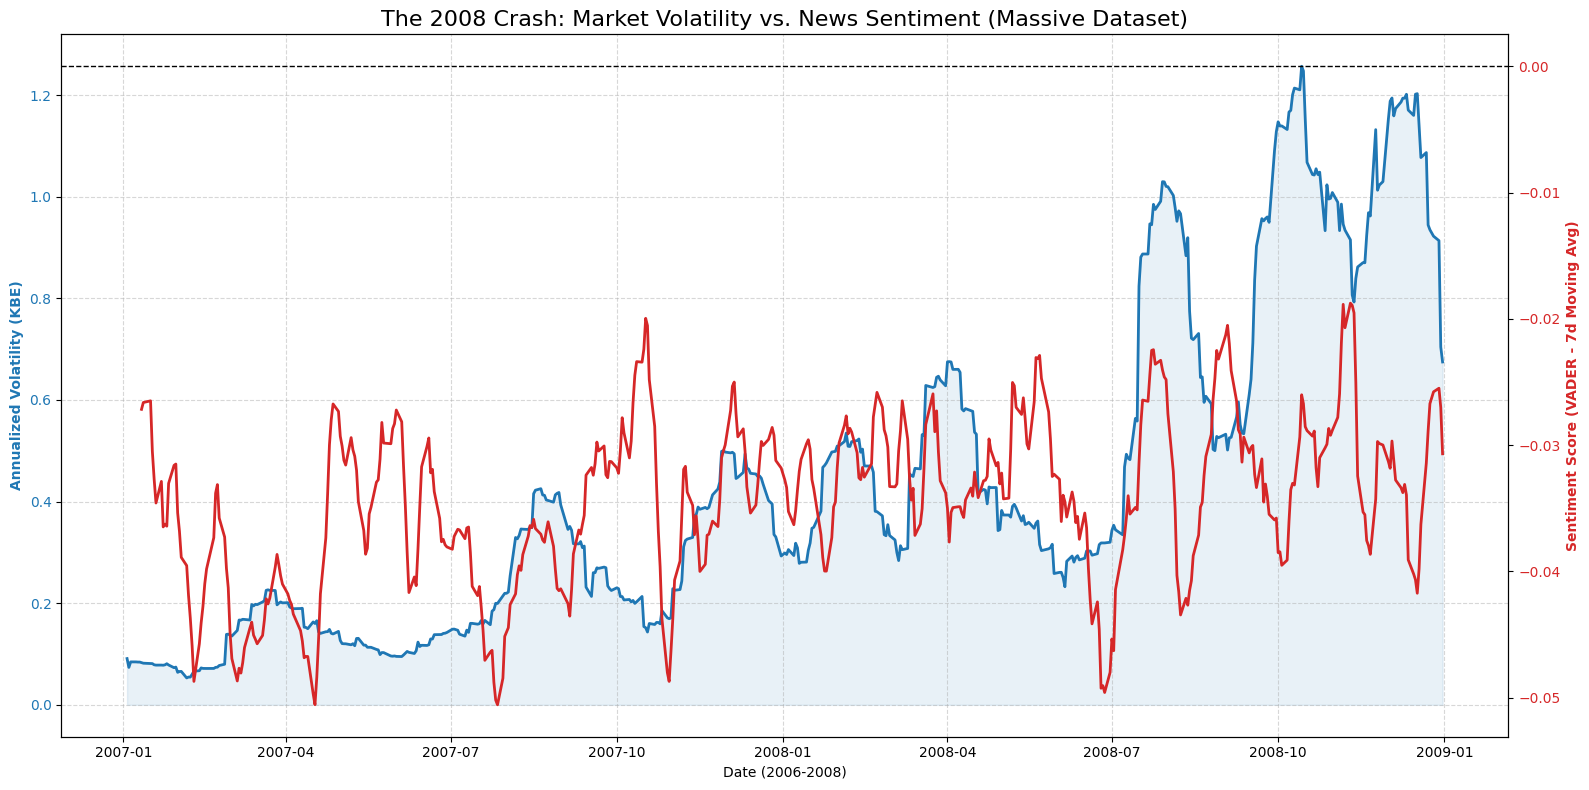

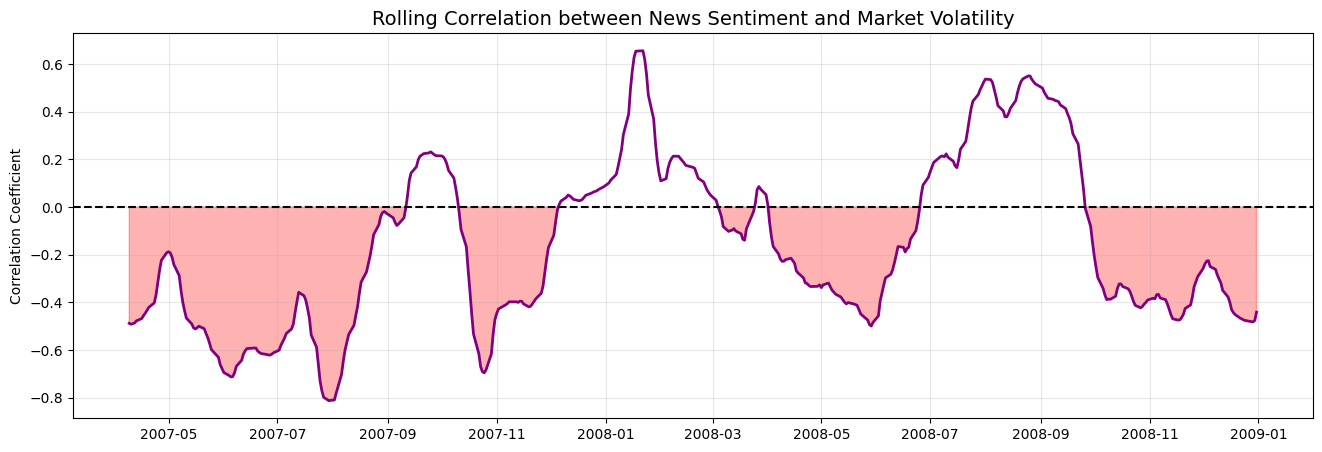

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement des données
df_sent = pd.read_csv('../data/daily_sentiment_agg_final.csv')
df_fine = pd.read_csv('../data/financial_data_KBE.csv')

# Conversion des dates
df_sent['date_only'] = pd.to_datetime(df_sent['date_only'])
df_fine['Date'] = pd.to_datetime(df_fine['Date']).dt.tz_localize(None) # Nettoyage timezone

# 2. Fusion des deux mondes
df_plot = pd.merge(df_fine, df_sent, left_on='Date', right_on='date_only', how='inner')

# 3. Lissage (Smoothing) pour mieux voir la tendance
# On calcule une moyenne mobile sur 7 jours pour le sentiment
df_plot['sentiment_smooth'] = df_plot['mean'].rolling(window=7).mean()

# 4. Création du graphique
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Axe 1 : Volatilité KBE (Banques) ---
color_vol = '#1f77b4' # Bleu pro
ax1.set_xlabel('Date (2006-2008)')
ax1.set_ylabel('Annualized Volatility (KBE)', color=color_vol, fontweight='bold')
ax1.plot(df_plot['Date'], df_plot['Volatility'], color=color_vol, lw=2, label='Market Volatility')
ax1.fill_between(df_plot['Date'], df_plot['Volatility'], alpha=0.1, color=color_vol)
ax1.tick_params(axis='y', labelcolor=color_vol)

# --- Axe 2 : Sentiment (NLP) ---
ax2 = ax1.twinx()
color_sent = '#d62728' # Rouge pro
ax2.set_ylabel('Sentiment Score (VADER - 7d Moving Avg)', color=color_sent, fontweight='bold')
ax2.plot(df_plot['Date'], df_plot['sentiment_smooth'], color=color_sent, lw=2, label='News Sentiment')
ax2.axhline(0, color='black', lw=1, ls='--') # Ligne de neutralité
ax2.tick_params(axis='y', labelcolor=color_sent)

# 5. Titre et mise en forme
plt.title('The 2008 Crash: Market Volatility vs. News Sentiment (Massive Dataset)', fontsize=16)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
fig.tight_layout()

plt.show()

# On calcule la corrélation glissante sur une fenêtre de 60 jours (3 mois de bourse)
df_plot['rolling_corr'] = df_plot['sentiment_smooth'].rolling(window=60).corr(df_plot['Volatility'])

# Affichage du graphique de corrélation temporelle
plt.figure(figsize=(16, 5))
plt.plot(df_plot['Date'], df_plot['rolling_corr'], color='purple', lw=2)
plt.axhline(0, color='black', linestyle='--')
plt.fill_between(df_plot['Date'], df_plot['rolling_corr'], 0, where=(df_plot['rolling_corr'] < 0), color='red', alpha=0.3)
plt.title('Rolling Correlation between News Sentiment and Market Volatility', fontsize=14)
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.show()